In [1]:
# importing major libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings 
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('loan_approval_dataset.csv').drop(columns='loan_id')

In [4]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [5]:
df.shape

(4269, 12)

In [6]:
#df.loan_status
df.columns.str.strip()

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

In [7]:
df.columns=df.columns.str.strip()

In [8]:
df.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

In [9]:
df.loan_status.unique()

array([' Approved', ' Rejected'], dtype=object)

In [10]:
df.loan_status=df.loan_status.map({' Approved':1, ' Rejected':0})

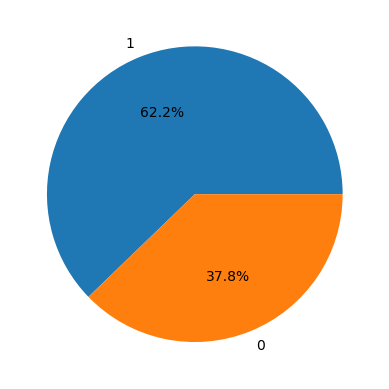

loan_status
1    2656
0    1613
Name: count, dtype: int64

In [11]:
plt.pie(df.loan_status.value_counts(),labels=df.loan_status.value_counts().index,autopct='%1.1f%%')
plt.show()
df.loan_status.value_counts()

In [12]:
df.education.unique()

df.education=df.education.str.strip()
df.self_employed=df.self_employed.str.strip()


In [13]:
# column transformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
l1 = ['Graduate','Not Graduate']
l2  =['No', 'Yes']
trans1 = ColumnTransformer([
    ('tr1',OneHotEncoder(categories=[l1],drop='first',dtype='int'),['education']),
    ('tr2',OneHotEncoder(categories=[l2],drop='first',dtype='int'),['self_employed']),
],remainder='passthrough')
trans1

ColumnTransformer(remainder='passthrough',
                  transformers=[('tr1',
                                 OneHotEncoder(categories=[['Graduate',
                                                            'Not Graduate']],
                                               drop='first', dtype='int'),
                                 ['education']),
                                ('tr2',
                                 OneHotEncoder(categories=[['No', 'Yes']],
                                               drop='first', dtype='int'),
                                 ['self_employed'])])

In [14]:
#df.education.unique()
#df.self_employed.unique()



In [15]:
x=df.iloc[:,0:-1]
y=df.loan_status


#train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
from sklearn.ensemble import RandomForestClassifier
rdc = RandomForestClassifier(max_depth=3,n_jobs=-1,n_estimators=101)
rdc

RandomForestClassifier(max_depth=3, n_estimators=101, n_jobs=-1)

In [17]:
# fit 
x_train = pd.DataFrame(trans1.fit_transform(x_train),columns=trans1.get_feature_names_out())  # fit_transform
x_test = pd.DataFrame(trans1.fit_transform(x_test),columns=trans1.get_feature_names_out())  #transform

In [18]:
rdc.fit(x_train,y_train)

RandomForestClassifier(max_depth=3, n_estimators=101, n_jobs=-1)

In [19]:
y_pred = rdc.predict(x_test)

from  sklearn.metrics import accuracy_score,precision_score,f1_score

print('accuracy',accuracy_score(y_test,y_pred))
print('precision',precision_score(y_test,y_pred))
print('f1_score',f1_score(y_test,y_pred))

accuracy 0.9590163934426229
precision 0.9980119284294234
f1_score 0.9663137632338787


In [20]:
#fitting
rdc.score(x_train,y_train)

0.9592972181551976

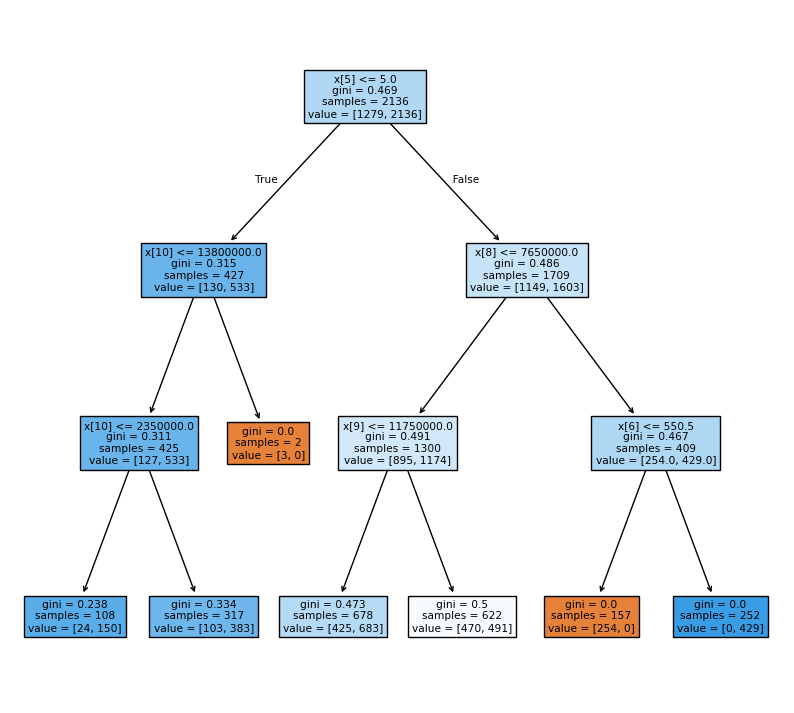

------------------------------------------------------------------------------------------------------------------------


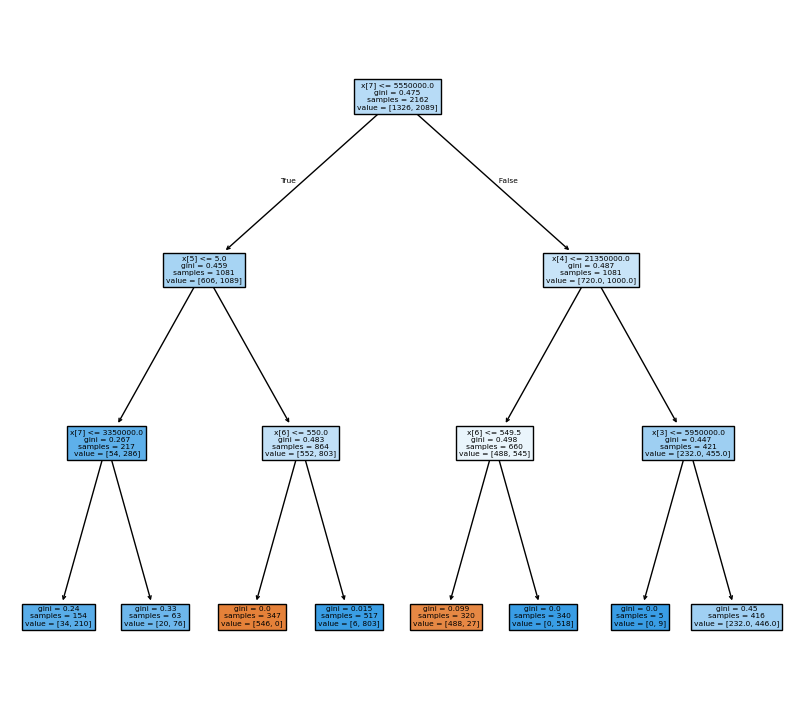

------------------------------------------------------------------------------------------------------------------------


In [21]:
from sklearn import tree
for i in range(2):
    plt.figure(figsize=(10,9)) 
    tree.plot_tree(rdc[i],filled=True)
    plt.show()
    print('-'*120)

In [22]:
rdc.feature_importances_

array([9.79050900e-05, 1.19428269e-03, 2.35442730e-03, 1.15087874e-02,
       1.79283664e-02, 1.32685216e-01, 7.94948119e-01, 1.08913036e-02,
       7.12170191e-03, 9.59546905e-03, 1.16744212e-02])

In [23]:
temp = pd.Series(rdc.feature_importances_,index=x_train.columns).reset_index()

In [24]:
temp.columns = ['feature','importance']
temp

,feature,importance
0,tr1__education_Not Graduate,0.000098
1,tr2__self_employed_Yes,0.001194
2,remainder__no_of_dependents,0.002354
3,remainder__income_annum,0.011509
4,remainder__loan_amount,0.017928
5,remainder__loan_term,0.132685
6,remainder__cibil_score,0.794948
7,remainder__residential_assets_value,0.010891
8,remainder__commercial_assets_value,0.007122
9,remainder__luxury_assets_value,0.009595


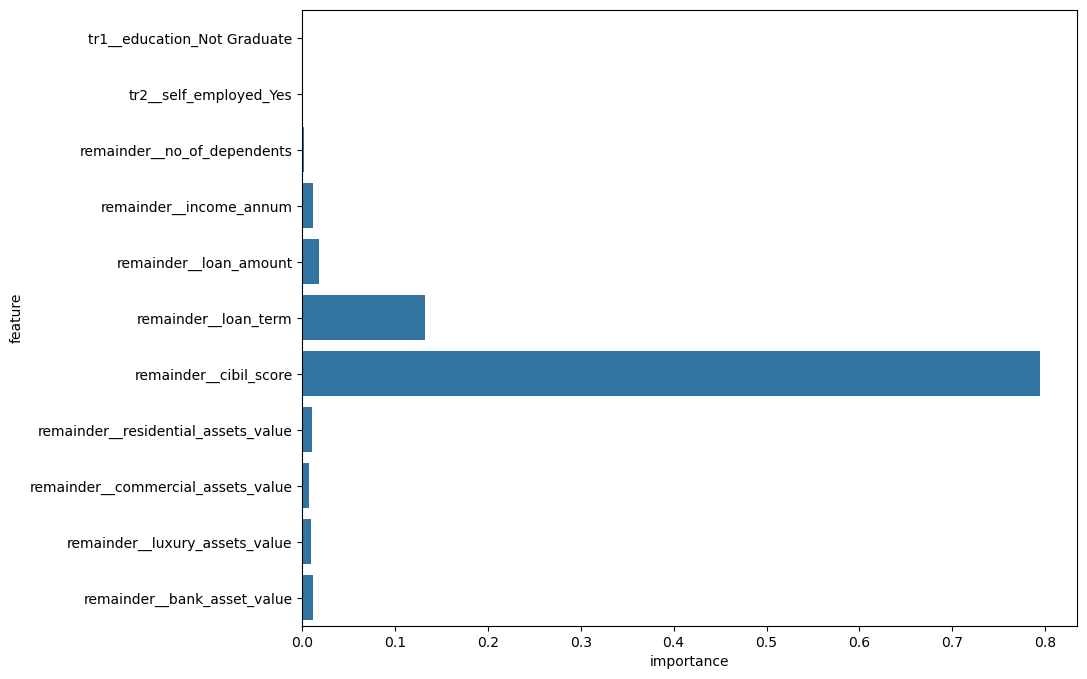

In [25]:
plt.figure(figsize=(10,8))
sns.barplot(data=temp,x='importance',y='feature')
plt.show()